In [2]:
import pypsa
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely.ops import nearest_points

In [4]:
# Load your solved PyPSA network
network = pypsa.Network("../results/128_wAT_entsoe_finetuned/networks/base_s_128_elec_.nc")

# Load your shapefile (original QGIS data)
lines_aut = gpd.read_file("qgis/lines_aut.shp")


INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


In [7]:
# Example: Look at network lines
network.lines.head()

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,i_nom,v_nom,dc
Line,,,,,,,,,,,,,,,,,,,,,
0,AL0 0,GR0 0,Al/St 240/40 4-bundle 380.0,90.270060,11.008544,0.0,0.001763,1787.476433,0.0,True,...,0.0,0.0,0.0,0.0,0.000625,0.000076,1787.477031,2.58,380.0,False
1,AL0 0,ME0 0,Al/St 240/40 4-bundle 380.0,28.301610,3.451416,0.0,0.000898,2279.032453,0.0,True,...,0.0,0.0,0.0,0.0,0.000196,0.000024,2743.469847,2.58,380.0,False
10,AT0 12,AT0 16,Al/St 240/40 4-bundle 380.0,33.535940,4.089749,0.0,0.000198,983.112038,0.0,True,...,0.0,0.0,0.0,0.0,0.000232,0.000028,983.112147,2.58,380.0,False
100,DE0 1,DE0 2,Al/St 240/40 4-bundle 380.0,31.086469,3.791033,0.0,0.002191,3396.205223,0.0,True,...,0.0,0.0,0.0,0.0,0.000215,0.000026,3396.205436,2.58,380.0,False
101,DE0 1,DE0 3,Al/St 240/40 4-bundle 380.0,3.759843,0.458517,0.0,0.006282,16534.157009,0.0,True,...,0.0,0.0,0.0,0.0,0.000026,0.000003,16534.157634,2.58,380.0,False


In [6]:
# Example: Look at shapefile fields
lines_aut.head()

,id,name,active,length,i_max,v_ref,r,x,c,comm,decomm,scenario,from_node,to_node,s_max,type,references,geometry
0,14001.0,182/1,1,5.360,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (377942.108 480212.213, 377943.906 ..."
1,14002.0,182/2,1,5.340,1077.0,110.0,0.0557,0.3824,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14003.0,205.196059,None,None,"LINESTRING (381270.464 484013.966, 381233.822 ..."
2,14003.0,182/7,1,6.220,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14003.0,14001.0,89.547027,None,None,"LINESTRING (378019.552 480229.434, 378092.088 ..."
3,14004.0,184/1,1,5.830,470.0,110.0,0.1690,0.4035,0.0000,2024-01-01,2100/01/01,AUT,14001.0,14002.0,89.547027,None,None,"LINESTRING (381223.187 484087.493, 381158.659 ..."
4,11030.0,127-9,1,16.189,470.0,110.0,0.2024,0.4329,6.0483,2024-01-01,2365/01/01,BGL,11002.0,11005.0,89.500000,None,None,"LINESTRING (666823.42 444499.182, 666780.956 4..."


In [ ]:
# Ensure shapefile is in WGS84 (lat/lon) or project both to a metric CRS (e.g., EPSG:3035 for Europe)
lines_aut = lines_aut.to_crs(epsg=4326)  # WGS84

In [9]:
def get_lines_as_geodataframe(network):
    bus_locs = network.buses[['x', 'y']]  # x, y in degrees
    line_geoms = []
    for idx, line in network.lines.iterrows():
        point0 = Point(bus_locs.loc[line.bus0, ['x', 'y']])
        point1 = Point(bus_locs.loc[line.bus1, ['x', 'y']])
        line_geoms.append(LineString([point0, point1]))
    gdf = gpd.GeoDataFrame(network.lines.copy(), geometry=line_geoms, crs="EPSG:4326")
    return gdf

pypsa_lines_gdf = get_lines_as_geodataframe(network)


In [10]:
# Find Austrian buses
austrian_buses = network.buses[network.buses['country'] == 'AT'].index

# Select lines connected to Austria
def is_crossborder(line):
    return (line.bus0 in austrian_buses) or (line.bus1 in austrian_buses)

pypsa_lines_aut = pypsa_lines_gdf[pypsa_lines_gdf.apply(is_crossborder, axis=1)]


In [11]:
# Build spatial index for shapefile
lines_aut_sindex = lines_aut.sindex

# Function to find closest shapefile line to each PyPSA line
def find_closest_shapefile_line(pypsa_line_geom):
    possible_matches_index = list(lines_aut_sindex.intersection(pypsa_line_geom.bounds))
    possible_matches = lines_aut.iloc[possible_matches_index]
    nearest = possible_matches.distance(pypsa_line_geom).sort_values().index[0]
    return nearest

# Find closest shapefile line for each PyPSA line
matched_indices = pypsa_lines_aut.geometry.apply(find_closest_shapefile_line)

# Join matched lines
pypsa_lines_aut['matched_index'] = matched_indices
matched_lines = pypsa_lines_aut.merge(lines_aut, left_on='matched_index', right_index=True, suffixes=('_pypsa', '_shp'))


/tmp/ipykernel_1034055/1043241619.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest = possible_matches.distance(pypsa_line_geom).sort_values().index[0]
/home/bjoern/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
# Calculate length (in km) if necessary
matched_lines['length_pypsa'] = matched_lines.geometry_pypsa.length * 111  # Approximate degree -> km
matched_lines['length_shp'] = matched_lines.geometry_shp.length * 111

# Error in line length
matched_lines['length_error_km'] = matched_lines['length_pypsa'] - matched_lines['length_shp']
matched_lines['length_error_percent'] = (matched_lines['length_error_km'] / matched_lines['length_shp']) * 100

# Capacity error (if shapefile has it)
if 'capacity' in matched_lines.columns:
    matched_lines['capacity_error'] = matched_lines['s_nom'] - matched_lines['capacity']

# Summary
print(matched_lines[['length_pypsa', 'length_shp', 'length_error_km', 'length_error_percent']].describe())


       length_pypsa  length_shp  length_error_km  length_error_percent
count     72.000000   72.000000        72.000000             72.000000
mean      70.319591   47.222931        23.096660            422.295751
std       66.676689   41.394624        81.974627           1142.861093
min        6.623061    0.569826      -142.038900            -89.594433
25%       21.600062   14.549554       -20.160768            -42.148737
50%       47.341733   40.882922         5.304184             21.879304
75%      101.272217   61.265894        61.700431            232.419584
max      298.956736  170.741618       264.248340           7731.780031


/tmp/ipykernel_1034055/1684795415.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  matched_lines['length_pypsa'] = matched_lines.geometry_pypsa.length * 111  # Approximate degree -> km
/tmp/ipykernel_1034055/1684795415.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  matched_lines['length_shp'] = matched_lines.geometry_shp.length * 111


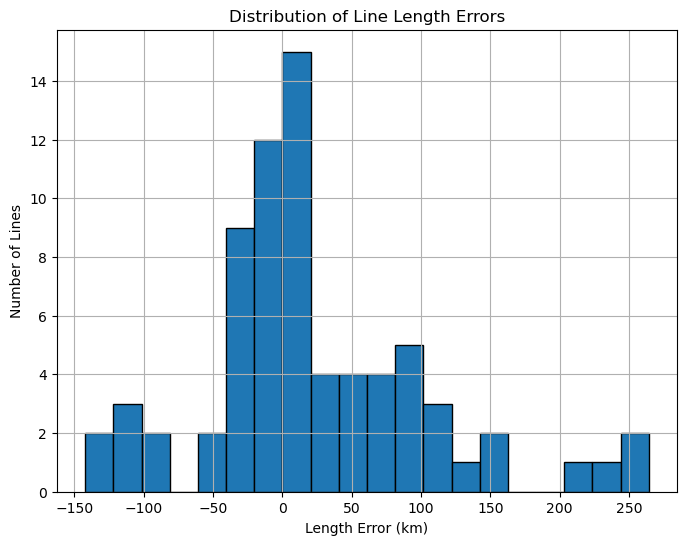

In [13]:
plt.figure(figsize=(8,6))
plt.hist(matched_lines['length_error_km'], bins=20, edgecolor='black')
plt.xlabel('Length Error (km)')
plt.ylabel('Number of Lines')
plt.title('Distribution of Line Length Errors')
plt.grid(True)
plt.show()


In [14]:
# Reproject PyPSA lines
pypsa_lines_aut_proj = pypsa_lines_aut.to_crs(epsg=3035)

# Reproject Shapefile lines
lines_aut_proj = lines_aut.to_crs(epsg=3035)

# Reproject matched lines (if already matched)
matched_lines['geometry_pypsa_proj'] = pypsa_lines_aut_proj.geometry.values
matched_lines['geometry_shp_proj'] = lines_aut_proj.loc[matched_lines['matched_index']].geometry.values


In [15]:
# Length in meters
matched_lines['length_pypsa_m'] = matched_lines['geometry_pypsa_proj'].length
matched_lines['length_shp_m'] = matched_lines['geometry_shp_proj'].length

# Convert meters to kilometers
matched_lines['length_pypsa_km'] = matched_lines['length_pypsa_m'] / 1000
matched_lines['length_shp_km'] = matched_lines['length_shp_m'] / 1000

# Error analysis
matched_lines['length_error_km'] = matched_lines['length_pypsa_km'] - matched_lines['length_shp_km']
matched_lines['length_error_percent'] = (matched_lines['length_error_km'] / matched_lines['length_shp_km']) * 100


In [16]:
matched_lines[['length_pypsa_km', 'length_shp_km', 'length_error_km', 'length_error_percent']].describe()


,length_pypsa_km,length_shp_km,length_error_km,length_error_percent
count,72.000000,72.000000,72.000000,72.000000
mean,54.635567,37.074656,17.560911,416.984981
std,49.912025,31.952407,61.686320,1160.005070
min,6.314502,0.401903,-102.582582,-90.692438
25%,16.510713,11.958201,-14.507715,-39.700755
50%,36.652217,29.469486,4.820981,21.235429
75%,78.000402,49.695305,49.426461,228.083580
max,207.392431,141.933141,183.007097,7979.881589


In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#import geopandas as gpd

In [20]:
# Reproject PyPSA and shapefile lines to WGS84
pypsa_lines_wgs84 = pypsa_lines_aut.to_crs(epsg=4326)
lines_aut_wgs84 = lines_aut.to_crs(epsg=4326)


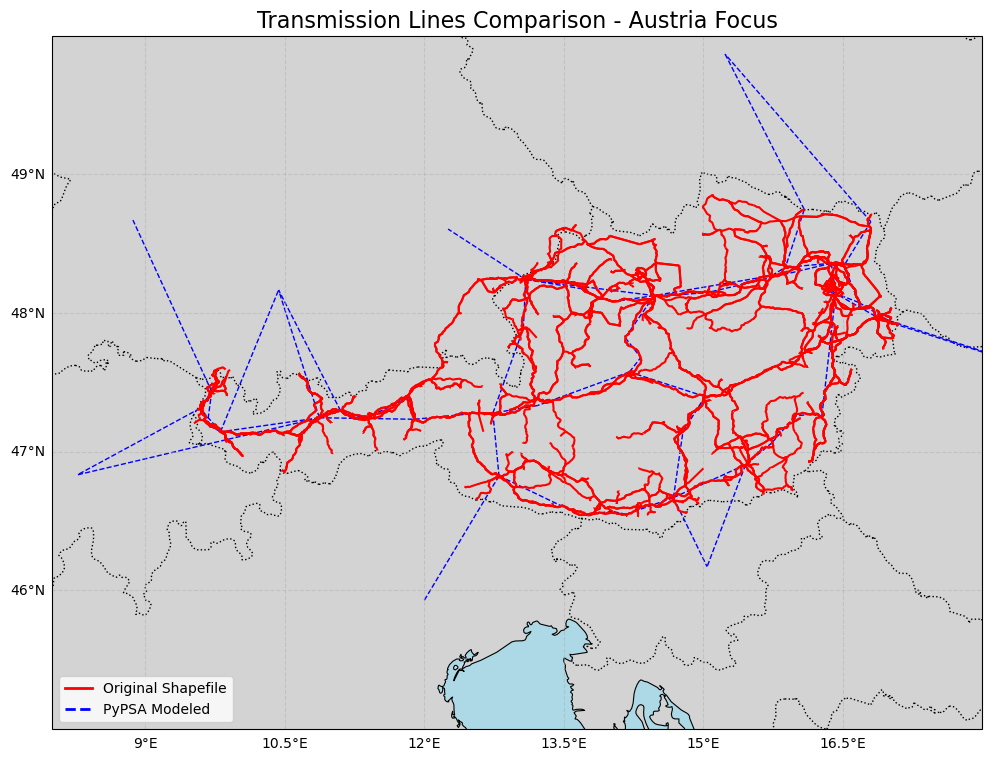

In [25]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Set background
ax.set_facecolor('white')

# Add cartopy built-in features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black', linewidth=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot shapefile lines
lines_aut_wgs84.plot(ax=ax, color='red', linewidth=1.5, label="Original Shapefile Lines", zorder=3)

# Plot PyPSA modeled lines
pypsa_lines_wgs84.plot(ax=ax, color='blue', linestyle='--', linewidth=1, label="PyPSA Modeled Lines", zorder=2)

# Set extent manually focused on Austria
# Austria approx: 9E to 17E, 46N to 49N
ax.set_extent([8, 18, 45, 50], crs=ccrs.PlateCarree())

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Title
plt.title('Transmission Lines Comparison - Austria Focus', fontsize=16)

# Create custom legend manually
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Original Shapefile'),
    Line2D([0], [0], color='blue', lw=2, linestyle='--', label='PyPSA Modeled'),
]
ax.legend(handles=legend_elements, loc='lower left')

plt.show()
